# 03 — Model Evaluation

Train/test evaluation for a single **experiment's** play-type classifier.
Set `EXPERIMENT_ID` in the config cell below to any id under
`artifacts/modeling/experiments/` (e.g. `exp_007`), or leave it `None` to use the
active experiment (`artifacts/modeling/active.json`). The model family
(`best_model`) and its resolved hyperparameters — including anything tuned via
Optuna — come from that experiment's `config.yaml`, so two experiments sharing the
same registry key (e.g. untuned vs tuned `xgboost`) evaluate distinctly.

Contents: metrics table (accuracy / precision / recall / F1 / support) → confusion
matrix → ROC curve → precision-recall curve, each shown for **train and test**.

## 0. Config — pick the experiment here

In [9]:
# ── The only knob: which experiment to evaluate ─────────────────────────────
# Any id under artifacts/modeling/experiments/ (e.g. "exp_007").
# None -> the active experiment (artifacts/modeling/active.json).
EXPERIMENT_ID = "exp_007"

TEST_SIZE = 0.2
SEED = 42                # matches the pipeline's StratifiedKFold seed
THRESHOLD = 0.5          # probability cutoff for class predictions

## 1. Setup

In [10]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Run everything from the repo root so repo-relative paths (parquet, configs)
# resolve exactly as they do for the CLI.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

from src.data.loaders import load_play_type_dataset
from src.data.schema import MODEL_REGISTRY_KEYS, TARGET_CLF
from src.models import CLASSIFIER_BUILDERS
from src.utils.experiment_profile import ExperimentProfile, use_experiment_profile
from src.utils.experiments import get_active_experiment, read_experiment_config

# Resolve the experiment and the model family it selected as best.
EXPERIMENT_ID = EXPERIMENT_ID or get_active_experiment()
assert EXPERIMENT_ID, "No EXPERIMENT_ID given and no active experiment set."
exp_cfg = read_experiment_config(EXPERIMENT_ID)
MODEL_KEY = exp_cfg["best_model"]
assert MODEL_KEY in MODEL_REGISTRY_KEYS, f"{MODEL_KEY!r} not in {MODEL_REGISTRY_KEYS}"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CLASS_NAMES = ["run", "pass"]   # target encoded pass=1 / run=0
print(f"Evaluating experiment {EXPERIMENT_ID} ({exp_cfg.get('name')}) -> best_model={MODEL_KEY}")

Evaluating experiment exp_007 (xgboost_tuned) -> best_model=xgboost


## 2. Load data, split, impute

Stratified train/test split on the modeling parquet (the current feature-selected
dataset). Median imputation is fit on **train only** and applied to both splits —
the same leakage-safe rule the CV pipeline uses.

In [11]:
X, y = load_play_type_dataset()
print(f"Dataset: {X.shape[0]:,} rows × {X.shape[1]} features | target '{TARGET_CLF}'")
print(f"Class balance: {dict(y.value_counts().rename({1: 'pass', 0: 'run'}))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Fit imputer on train, transform both (one-hot cols have no NaN; harmless).
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=X.columns, index=X_test.index
)
print(f"Train: {len(X_train_imp):,}  |  Test: {len(X_test_imp):,}")

Dataset: 276,286 rows × 65 features | target 'play_type'
Class balance: {'pass': 160936, 'run': 115350}
Train: 221,028  |  Test: 55,258


## 3. Build and fit the model

The estimator and its hyperparameters are resolved from the experiment's
`config.yaml` (`models.<best_model>.hyperparameters`) — the exact params that run
recorded, including Optuna-tuned values. Refit on the train split here (the
persisted `best_model.joblib`, when it exists, is fit on *full* data and would
leak into this holdout).

In [12]:
# Resolved (possibly tuned) hyperparameters recorded for this experiment's best model.
hp = dict(exp_cfg["models"][MODEL_KEY]["hyperparameters"])
profile = ExperimentProfile(
    name=exp_cfg.get("name", EXPERIMENT_ID),
    description=exp_cfg.get("description"),
    seed=int(exp_cfg.get("seed", SEED)),
    n_folds=int(exp_cfg.get("n_folds", 5)),
    persist_best=False,
    models={MODEL_KEY: hp},
)

with use_experiment_profile(profile):
    model = CLASSIFIER_BUILDERS[MODEL_KEY]()
    model.fit(X_train_imp, y_train)

print(f"Fitted {MODEL_KEY} from experiment {EXPERIMENT_ID} ({profile.name})")
print("Hyperparameters:", profile.model_hyperparameters(MODEL_KEY))

# Predicted P(pass) and hard labels for both splits.
proba_train = model.predict_proba(X_train_imp)[:, 1]
proba_test = model.predict_proba(X_test_imp)[:, 1]
pred_train = (proba_train >= THRESHOLD).astype(int)
pred_test = (proba_test >= THRESHOLD).astype(int)

Fitted xgboost from experiment exp_007 (xgboost_tuned)
Hyperparameters: {'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0, 'n_estimators': 800, 'max_depth': 9, 'learning_rate': 0.011624228953947071, 'subsample': 0.7094987150323492, 'colsample_bytree': 0.9886119673694892, 'min_child_weight': 12, 'reg_lambda': 0.9327893590138686, 'reg_alpha': 0.05277458621594773, 'gamma': 2.4773180191777024}


## 4. Metrics table

Accuracy, precision, recall, F1-score, and support — per class plus macro/weighted
averages, for train and test side by side.

In [13]:
def metrics_frame(y_true, y_pred, split_label):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    df = pd.DataFrame(report).T
    df["support"] = df["support"].astype(int)
    # Flatten the scalar accuracy row into the same columns.
    acc = accuracy_score(y_true, y_pred)
    df.loc["accuracy", ["precision", "recall", "f1-score"]] = [np.nan, np.nan, acc]
    df.loc["accuracy", "support"] = len(y_true)
    df.columns = pd.MultiIndex.from_product([[split_label], df.columns])
    return df

train_metrics = metrics_frame(y_train, pred_train, "train")
test_metrics = metrics_frame(y_test, pred_test, "test")
metrics_table = pd.concat([train_metrics, test_metrics], axis=1)

print(f"{MODEL_KEY} — classification metrics (threshold={THRESHOLD})")
print(f"ROC-AUC  train={roc_auc_score(y_train, proba_train):.4f}  "
      f"test={roc_auc_score(y_test, proba_test):.4f}")
metrics_table.round(4)

xgboost — classification metrics (threshold=0.5)
ROC-AUC  train=0.8471  test=0.8165


train                               test                   \
             precision  recall f1-score support precision  recall f1-score   
run             0.7246  0.7067   0.7155   92280    0.7025  0.6834   0.6928   
pass            0.7934  0.8075   0.8004  128748    0.7774  0.7925   0.7849   
accuracy           NaN     NaN   0.7654  221028       NaN     NaN   0.7470   
macro avg       0.7590  0.7571   0.7579  221028    0.7400  0.7380   0.7389   
weighted avg    0.7647  0.7654   0.7649  221028    0.7461  0.7470   0.7465   

                      
             support  
run            23070  
pass           32188  
accuracy       55258  
macro avg      55258  
weighted avg   55258

## 5. Confusion matrix — train and test

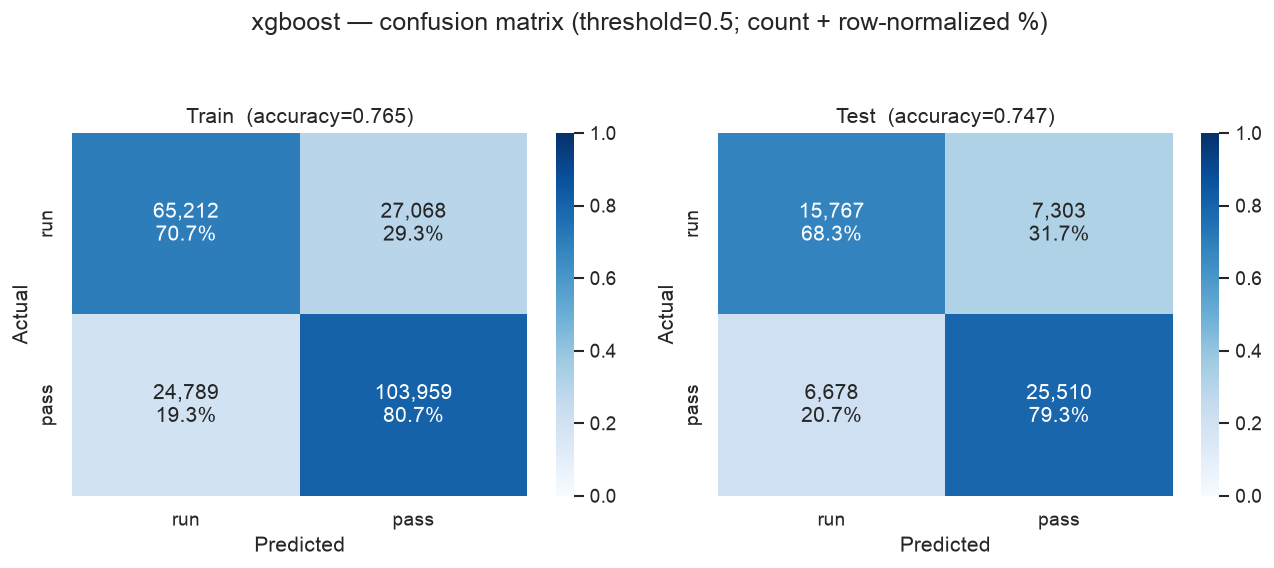

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (yt, yp, label) in zip(
    axes,
    [(y_train, pred_train, "Train"), (y_test, pred_test, "Test")],
):
    cm = confusion_matrix(yt, yp)
    acc = accuracy_score(yt, yp)
    # Row-normalized proportions (share of each actual class).
    cm_prop = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]:,}\n{cm_prop[i, j]:.1%}" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    sns.heatmap(
        cm_prop, annot=annot, fmt="", cmap="Blues", cbar=True,
        vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(f"{label}  (accuracy={acc:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle(
    f"{MODEL_KEY} — confusion matrix (threshold={THRESHOLD}; "
    "count + row-normalized %)", y=1.05,
)
plt.tight_layout()
plt.show()

## 6. ROC curve — train and test

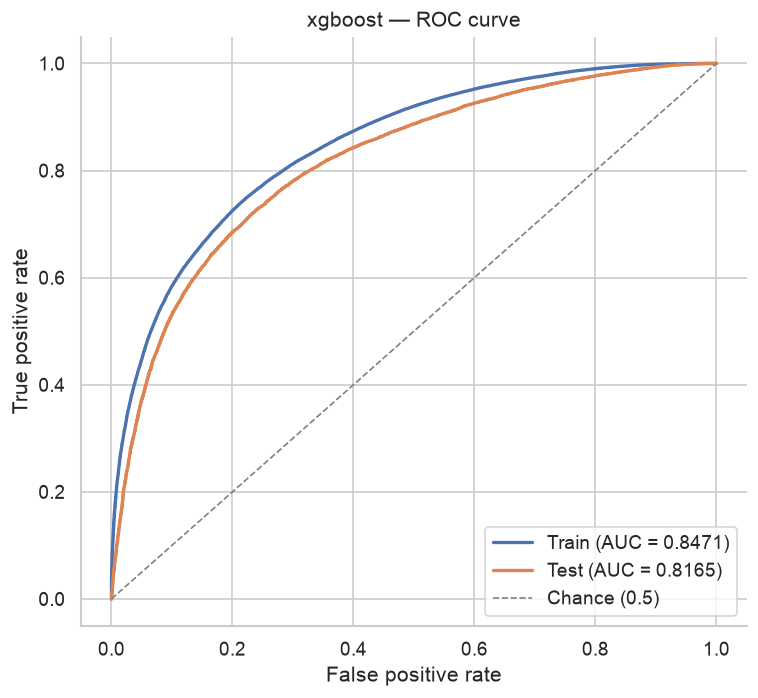

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, yt, label in [
    (proba_train, y_train, "Train"),
    (proba_test, y_test, "Test"),
]:
    fpr, tpr, _ = roc_curve(yt, proba)
    auc = roc_auc_score(yt, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], ls="--", c="gray", lw=1, label="Chance (0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"{MODEL_KEY} — ROC curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Precision-recall curve — train and test

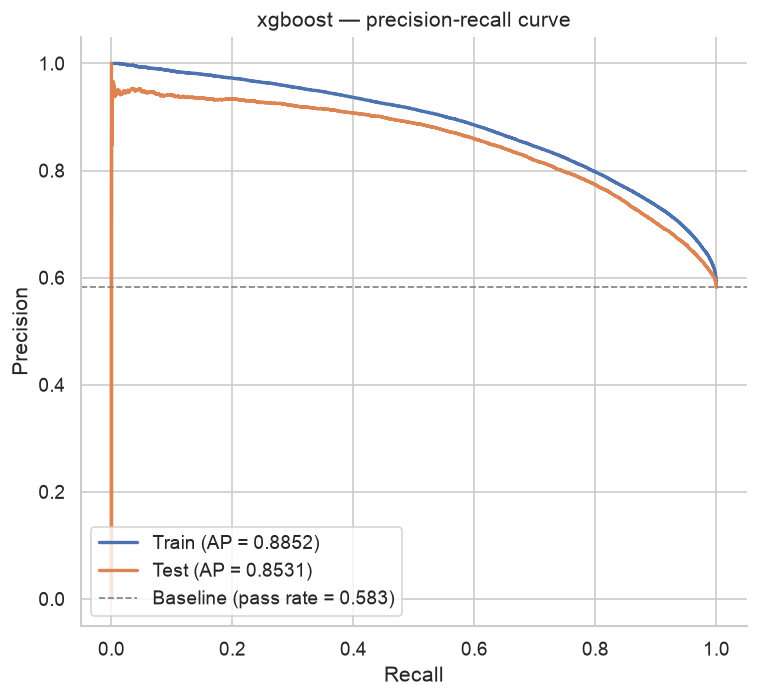

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, yt, label in [
    (proba_train, y_train, "Train"),
    (proba_test, y_test, "Test"),
]:
    precision, recall, _ = precision_recall_curve(yt, proba)
    ap = average_precision_score(yt, proba)
    ax.plot(recall, precision, lw=2, label=f"{label} (AP = {ap:.4f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, ls="--", c="gray", lw=1,
           label=f"Baseline (pass rate = {baseline_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"{MODEL_KEY} — precision-recall curve")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()